# Project-Specific Robustness / Ablation Study

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
X_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_train_preprocessed.csv")
X_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_test_preprocessed.csv")

y_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_train_preprocessed.csv")
y_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_test_preprocessed.csv")

print(X_train.shape)
print(y_train.shape)

(279, 3)
(279, 1)


## Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

best_lr= LogisticRegression(
    C=0.1,
    solver="liblinear",
    random_state=42
)

best_lr.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=0.1, random_state=42, solver='liblinear')

## SVM

In [8]:
from sklearn.svm import SVC

best_svm= SVC(
    kernel="linear",
    random_state=42
)

best_svm.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=42)

## Load The original Dataset

In [12]:
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Dataset.csv")

X = df[["Analog value","Analog Voltage","NTU"]]
y = df["Binary bit S"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [13]:
test_df = X_test_raw.copy()

test_df["Actual"] = y_test.values

print(test_df.head())

     Analog value  Analog Voltage     NTU  Actual
25            141        0.688477  1-2NTU       1
80             97        0.473633  2-3NTU       0
275            70        0.341797  4-5NTU       0
237           137        0.668945  3-4NTU       1
350            78        0.380859  5-6NTU       1


In [14]:
test_df["SVM_Pred"] = best_svm.predict(X_test)

test_df["LR_Pred"] = best_lr.predict(X_test)

In [15]:
print(test_df["NTU"].unique())

['1-2NTU' '2-3NTU' '4-5NTU' '3-4NTU' '5-6NTU']


## NTU-wise Evaluation Function

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_by_ntu(df, pred_col):

    results = []

    for ntu in sorted(df["NTU"].unique()):

        subset = df[df["NTU"] == ntu]

        y_true = subset["Actual"]

        y_pred = subset[pred_col]

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        ber = (
            y_true != y_pred
        ).sum() / len(y_true)

        results.append([
            ntu,
            accuracy,
            precision,
            recall,
            f1,
            ber
        ])

    return pd.DataFrame(
        results,
        columns=[
            "NTU",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "BER"
        ]
    )

## SVM NTU-wise Results

In [17]:
svm_ntu_results = evaluate_by_ntu(
    test_df,
    "SVM_Pred"
)

print(svm_ntu_results)

      NTU  Accuracy  Precision  Recall     F1       BER
0  1-2NTU  1.000000   1.000000     1.0  1.000  0.000000
1  2-3NTU  0.928571   0.818182     1.0  0.900  0.071429
2  3-4NTU  0.894737   0.777778     1.0  0.875  0.105263
3  4-5NTU  0.608696   0.000000     0.0  0.000  0.391304
4  5-6NTU  0.529412   0.000000     0.0  0.000  0.470588


## Logistic Regression NTU-wise Results

In [18]:
lr_ntu_results = evaluate_by_ntu(
    test_df,
    "LR_Pred"
)

print(lr_ntu_results)

      NTU  Accuracy  Precision  Recall        F1       BER
0  1-2NTU  1.000000   1.000000     1.0  1.000000  0.000000
1  2-3NTU  0.928571   0.818182     1.0  0.900000  0.071429
2  3-4NTU  0.894737   0.777778     1.0  0.875000  0.105263
3  4-5NTU  0.565217   0.000000     0.0  0.000000  0.434783
4  5-6NTU  0.500000   0.470588     0.5  0.484848  0.500000


## Accuracy vs NTU Plot

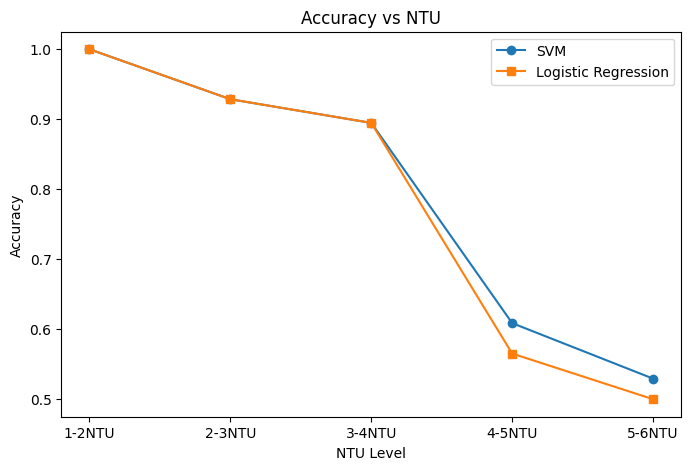

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    svm_ntu_results["NTU"],
    svm_ntu_results["Accuracy"],
    marker="o",
    label="SVM"
)

plt.plot(
    lr_ntu_results["NTU"],
    lr_ntu_results["Accuracy"],
    marker="s",
    label="Logistic Regression"
)

plt.xlabel("NTU Level")
plt.ylabel("Accuracy")

plt.title("Accuracy vs NTU")

plt.legend()

plt.show()

## BER vs NTU Plot

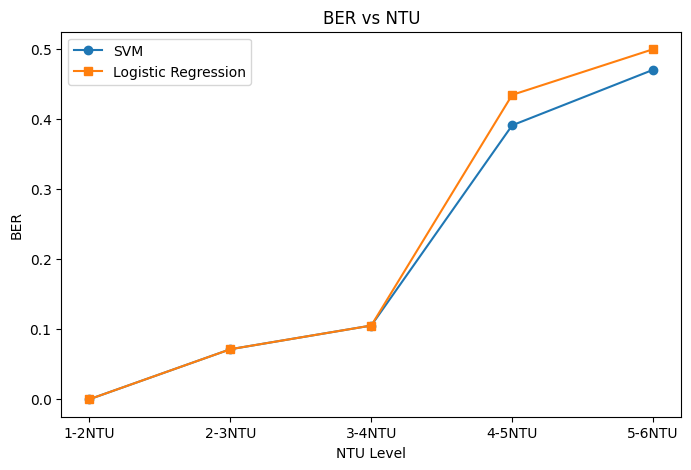

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    svm_ntu_results["NTU"],
    svm_ntu_results["BER"],
    marker="o",
    label="SVM"
)

plt.plot(
    lr_ntu_results["NTU"],
    lr_ntu_results["BER"],
    marker="s",
    label="Logistic Regression"
)

plt.xlabel("NTU Level")
plt.ylabel("BER")

plt.title("BER vs NTU")

plt.legend()

plt.show()